In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('SaaSData/Subscription Fatigue.csv')
df.head()

,Customer_ID,Age,Income_Level,Number_of_Subscriptions,Avg_Usage_Hours_Per_Week,App_Switch_Frequency,Discount_Used,Customer_Support_Interactions,Payment_Mode,Tenure_Months,Device_Type,Satisfaction_Score,Monthly_Total_Spend,Will_Cancel_Next_3_Months
0,1,56,Medium,5,8.1,7,0,1,Credit Card,45,Android,7,713.00,0
1,2,46,High,10,11.3,0,0,2,Wallet,35,Android,4,1162.31,0
2,3,32,Medium,6,6.2,8,0,1,Debit Card,45,iOS,5,545.97,0
3,4,60,Medium,5,4.6,6,1,4,Credit Card,26,Web,6,609.55,0
4,5,25,Medium,4,5.8,13,1,3,Wallet,36,Android,8,541.72,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15946 entries, 0 to 15945
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    15946 non-null  int64  
 1   Age                            15946 non-null  int64  
 2   Income_Level                   15946 non-null  object 
 3   Number_of_Subscriptions        15946 non-null  int64  
 4   Avg_Usage_Hours_Per_Week       15946 non-null  float64
 5   App_Switch_Frequency           15946 non-null  int64  
 6   Discount_Used                  15946 non-null  int64  
 7   Customer_Support_Interactions  15946 non-null  int64  
 8   Payment_Mode                   15946 non-null  object 
 9   Tenure_Months                  15946 non-null  int64  
 10  Device_Type                    15946 non-null  object 
 11  Satisfaction_Score             15946 non-null  int64  
 12  Monthly_Total_Spend            15946 non-null 

In [4]:
df.isnull().sum()

Customer_ID                      0
Age                              0
Income_Level                     0
Number_of_Subscriptions          0
Avg_Usage_Hours_Per_Week         0
App_Switch_Frequency             0
Discount_Used                    0
Customer_Support_Interactions    0
Payment_Mode                     0
Tenure_Months                    0
Device_Type                      0
Satisfaction_Score               0
Monthly_Total_Spend              0
Will_Cancel_Next_3_Months        0
dtype: int64

In [5]:
df.shape

(15946, 14)

In [6]:
df_copy = df.drop(['Customer_ID'], axis=1)
df_copy

,Age,Income_Level,Number_of_Subscriptions,Avg_Usage_Hours_Per_Week,App_Switch_Frequency,Discount_Used,Customer_Support_Interactions,Payment_Mode,Tenure_Months,Device_Type,Satisfaction_Score,Monthly_Total_Spend,Will_Cancel_Next_3_Months
0,56,Medium,5,8.1,7,0,1,Credit Card,45,Android,7,713.00,0
1,46,High,10,11.3,0,0,2,Wallet,35,Android,4,1162.31,0
2,32,Medium,6,6.2,8,0,1,Debit Card,45,iOS,5,545.97,0
3,60,Medium,5,4.6,6,1,4,Credit Card,26,Web,6,609.55,0
4,25,Medium,4,5.8,13,1,3,Wallet,36,Android,8,541.72,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15941,64,Low,11,11.2,8,0,9,Wallet,41,Android,10,608.35,1
15942,32,Medium,8,8.4,12,0,0,Debit Card,3,iOS,9,719.74,0
15943,59,Low,5,10.9,14,1,5,UPI,38,Android,10,146.68,0
15944,41,Medium,5,5.2,14,1,8,Credit Card,41,Android,5,458.52,0


In [7]:
df_copy['Income_Level'].value_counts()

Income_Level
Medium    7120
Low       5648
High      3178
Name: count, dtype: int64

In [8]:
df_copy['Payment_Mode'].value_counts()

Payment_Mode
UPI            4036
Credit Card    4030
Debit Card     4021
Wallet         3859
Name: count, dtype: int64

In [9]:
df_copy['Device_Type'].value_counts()

Device_Type
Android    9588
iOS        4768
Web        1590
Name: count, dtype: int64

In [10]:
df_copy['Will_Cancel_Next_3_Months'].value_counts()

Will_Cancel_Next_3_Months
0    11298
1     4648
Name: count, dtype: int64

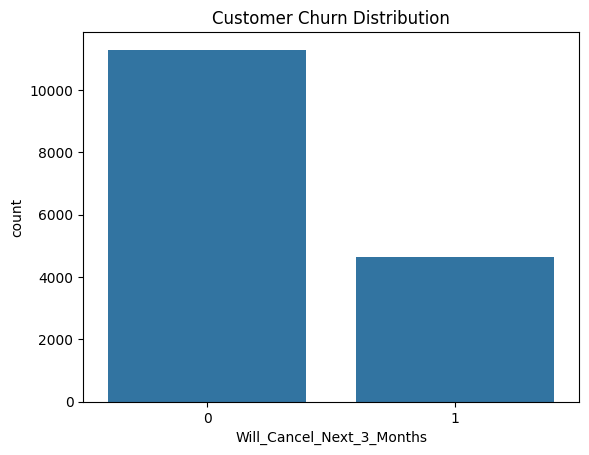

In [11]:
## Target Distribution

sns.countplot(x='Will_Cancel_Next_3_Months', data=df_copy)
plt.title("Customer Churn Distribution")
plt.show()

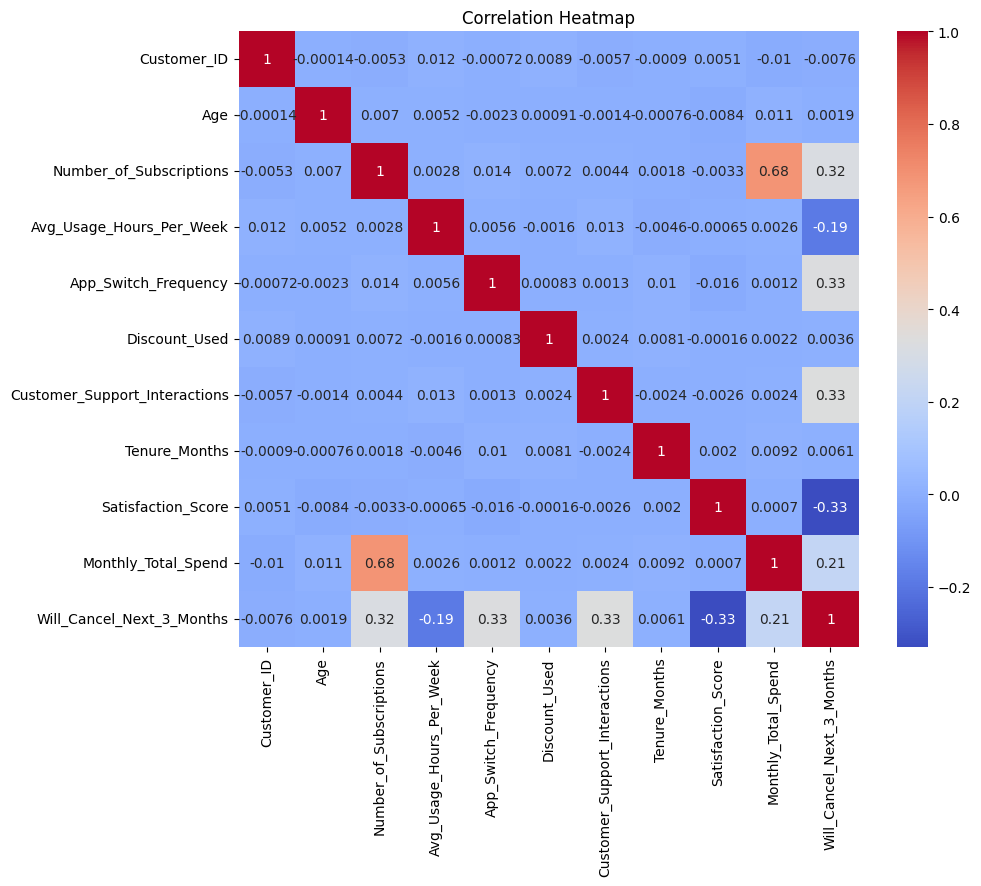

In [12]:
## Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

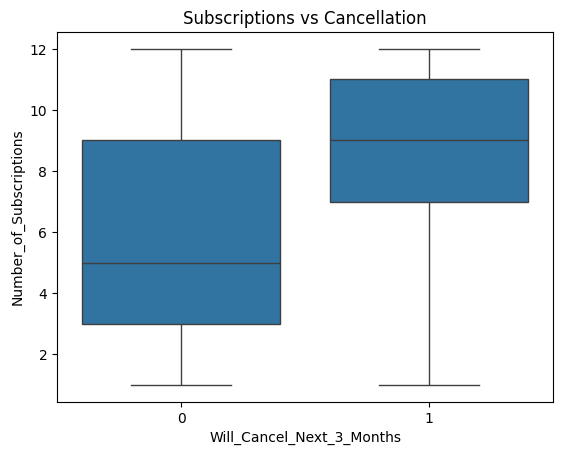

In [13]:
## Subscriptions vs Cancellation

sns.boxplot(x="Will_Cancel_Next_3_Months",
            y="Number_of_Subscriptions",
            data=df_copy)
plt.title("Subscriptions vs Cancellation")
plt.show()

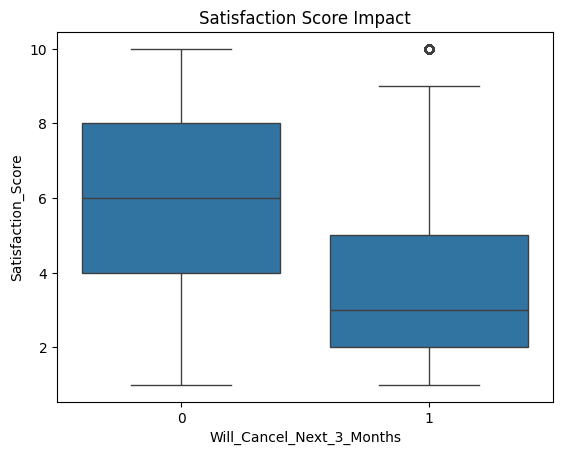

In [14]:
## Satisfaction vs Cancellation

sns.boxplot(x="Will_Cancel_Next_3_Months",
            y="Satisfaction_Score",
            data=df)
plt.title("Satisfaction Score Impact")
plt.show()

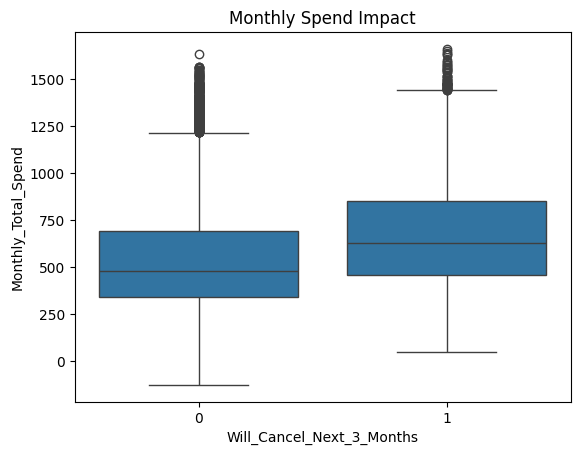

In [15]:
## Monthly Spend vs Cancellation

sns.boxplot(x="Will_Cancel_Next_3_Months",
            y="Monthly_Total_Spend",
            data=df)
plt.title("Monthly Spend Impact")
plt.show()